# Kalshi Temperature Market Backtest Analysis

This notebook runs a backtest of two trading strategies on simulated Kalshi daily high temperature contracts, comparing our bias-correction neural network against raw NWP model baselines.

## 1. Setup and Data Loading

In [1]:
import sys, os
os.chdir(os.path.dirname(os.path.abspath("kalshi_notebook.ipynb")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from kalshi_backtest import (
    generate_contracts, generate_single_nwp_contracts,
    backtest_hold_to_expiry, backtest_convergence_trade,
    compute_metrics, metrics_by_city, metrics_by_month,
    run_sensitivity, CONTRACTS_PER_TRADE, NWP_COLS,
)
from economic_data_prep import load_test_with_nwp
import config as cfg

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

df = load_test_with_nwp()
print(f"Loaded {len(df):,} rows  |  Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Cities: {df['ticker'].nunique()}")
df.head(3)

Loaded 7,300 rows  |  Columns: 12
Date range: 2025-04-17 to 2026-04-16
Cities: 20


,date,ticker,mu,sigma,y_true,fcst_gfs_global,fcst_ecmwf_ifs025,fcst_icon_seamless,fcst_gem_seamless,fcst_jma_seamless,fcst_ncep_hrrr_conus,nwp_ensemble_mean
0,2025-04-17,KXHIGHAUS,87.318017,1.138232,89.0,87.4,87.2,86.9,88.2,81.6,86.2,86.250000
1,2025-04-18,KXHIGHAUS,91.412036,1.110865,91.0,90.4,90.5,90.4,90.7,84.2,90.6,89.466667
2,2025-04-19,KXHIGHAUS,84.003868,1.317719,85.0,87.4,81.6,82.6,85.0,79.5,83.7,83.300000


## 2. Contract Generation

In [2]:
contracts = generate_contracts(df)
print(f"Contracts generated: {contracts.shape}")
print(f"Columns: {contracts.columns.tolist()}")
print(f"\nEdge distribution:")
print(contracts["edge"].describe().to_string())
contracts.sample(5, random_state=42)

Contracts generated: (71532, 10)
Columns: ['date', 'ticker', 'threshold', 'model_prob', 'market_prob', 'edge', 'settlement', 'y_true', 'mu', 'sigma']

Edge distribution:
count    7.153200e+04
mean     2.777429e-02
std      1.240320e-01
min     -8.438579e-01
25%     -2.756207e-12
50%      0.000000e+00
75%      8.475813e-05
max      9.239680e-01


,date,ticker,threshold,model_prob,market_prob,edge,settlement,y_true,mu,sigma
32157,2026-04-11,KXHIGHTBOS,40,1.000000,1.000000,0.000000e+00,1.0,60.0,59.373940,1.934875
47235,2025-06-18,KXHIGHTMIN,65,1.000000,1.000000,2.408467e-07,1.0,84.0,81.537383,1.521686
17598,2026-03-07,KXHIGHMIA,80,0.999200,0.480945,5.182553e-01,1.0,83.0,84.057075,1.285491
30223,2025-09-14,KXHIGHTBOS,65,1.000000,0.999662,3.381799e-04,1.0,75.0,74.194204,1.518577
38500,2026-01-08,KXHIGHTDC,55,0.976598,0.428033,5.485645e-01,0.0,55.0,57.748575,1.382539


## 3. Strategy A: Hold to Expiry

In [3]:
trades_a = backtest_hold_to_expiry(contracts)
metrics_a = compute_metrics(trades_a, "Strategy A: Hold to Expiry")

print(f"Strategy A: Hold to Expiry")
print(f"{'='*50}")
for k, v in metrics_a.items():
    if k == "label":
        continue
    if isinstance(v, float):
        if "rate" in k:
            print(f"  {k:<22s} {v:.1%}")
        elif "pnl" in k or "drawdown" in k:
            print(f"  {k:<22s} ${v:>12,.2f}")
        else:
            print(f"  {k:<22s} {v:.2f}")
    else:
        print(f"  {k:<22s} {v:>12,}")

Strategy A: Hold to Expiry
  n_trades                      8,785
  total_pnl              $  568,792.45
  avg_pnl_per_trade      $       64.75
  win_rate               71.1%
  sharpe                 51.23
  max_drawdown           $       -5.49
  trading_days                    365


## 4. Strategy B: Convergence Trade with Stop-Loss

In [4]:
trades_b = backtest_convergence_trade(contracts)
metrics_b = compute_metrics(trades_b, "Strategy B: Convergence + Stop-Loss")

print(f"Strategy B: Convergence + Stop-Loss")
print(f"{'='*50}")
for k, v in metrics_b.items():
    if k == "label":
        continue
    if isinstance(v, float):
        if "rate" in k:
            print(f"  {k:<22s} {v:.1%}")
        elif "pnl" in k or "drawdown" in k:
            print(f"  {k:<22s} ${v:>12,.2f}")
        else:
            print(f"  {k:<22s} {v:.2f}")
    else:
        print(f"  {k:<22s} {v:>12,}")

if "exit_type" in trades_b.columns:
    print(f"\nExit type distribution:")
    counts = trades_b["exit_type"].value_counts()
    for exit_type, count in counts.items():
        print(f"  {exit_type:<20s} {count:>6,} ({count/len(trades_b)*100:.1f}%)")

Strategy B: Convergence + Stop-Loss
  n_trades                      8,785
  total_pnl              $  196,998.95
  avg_pnl_per_trade      $       22.42
  win_rate               71.1%
  sharpe                 32.88
  max_drawdown           $     -271.17
  trading_days                    365

Exit type distribution:
  convergence           6,244 (71.1%)
  stop_loss             2,541 (28.9%)


## 5. NWP Baseline Comparison (Strategy A)

In [5]:
nwp_models = {
    "GFS": "fcst_gfs_global",
    "HRRR": "fcst_ncep_hrrr_conus",
    "ECMWF": "fcst_ecmwf_ifs025",
}

# Compute historical std for each NWP model
nwp_stds = {}
for name, col in nwp_models.items():
    nwp_stds[name] = (df[col] - df["y_true"]).std()
    print(f"{name} historical std: {nwp_stds[name]:.2f} F")

# Run backtests for each NWP model
nwp_results = {}
for name, col in nwp_models.items():
    nwp_contracts = generate_single_nwp_contracts(df, col, nwp_stds[name])
    t_a = backtest_hold_to_expiry(nwp_contracts)
    nwp_results[name] = {
        "trades_a": t_a,
        "metrics_a": compute_metrics(t_a, f"{name} (Strategy A)"),
    }

# Build comparison table
nn_metrics = compute_metrics(trades_a, "NN Ensemble")
rows = [{"Model": "NN Ensemble",
         "Trades": nn_metrics["n_trades"],
         "Total P&L ($)": nn_metrics["total_pnl"],
         "Win Rate": nn_metrics["win_rate"],
         "Sharpe": nn_metrics["sharpe"]}]

for name in nwp_models:
    m = nwp_results[name]["metrics_a"]
    rows.append({"Model": name,
                 "Trades": m.get("n_trades", 0),
                 "Total P&L ($)": m.get("total_pnl", 0),
                 "Win Rate": m.get("win_rate", 0),
                 "Sharpe": m.get("sharpe", 0)})

comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df.style.format({
    "Trades": "{:,}",
    "Total P&L ($)": "${:,.2f}",
    "Win Rate": "{:.1%}",
    "Sharpe": "{:.2f}",
})

GFS historical std: 3.06 F
HRRR historical std: 2.94 F
ECMWF historical std: 3.08 F


,Trades,Total P&L ($),Win Rate,Sharpe
Model,,,,
NN Ensemble,"8,785","$568,792.45",71.1%,51.23
GFS,"9,984","$161,723.33",33.3%,13.32
HRRR,"9,924","$228,380.54",38.5%,19.23
ECMWF,"8,732","$-50,973.11",24.3%,-4.61


## 6. Cumulative P&L: Strategy A vs Strategy B

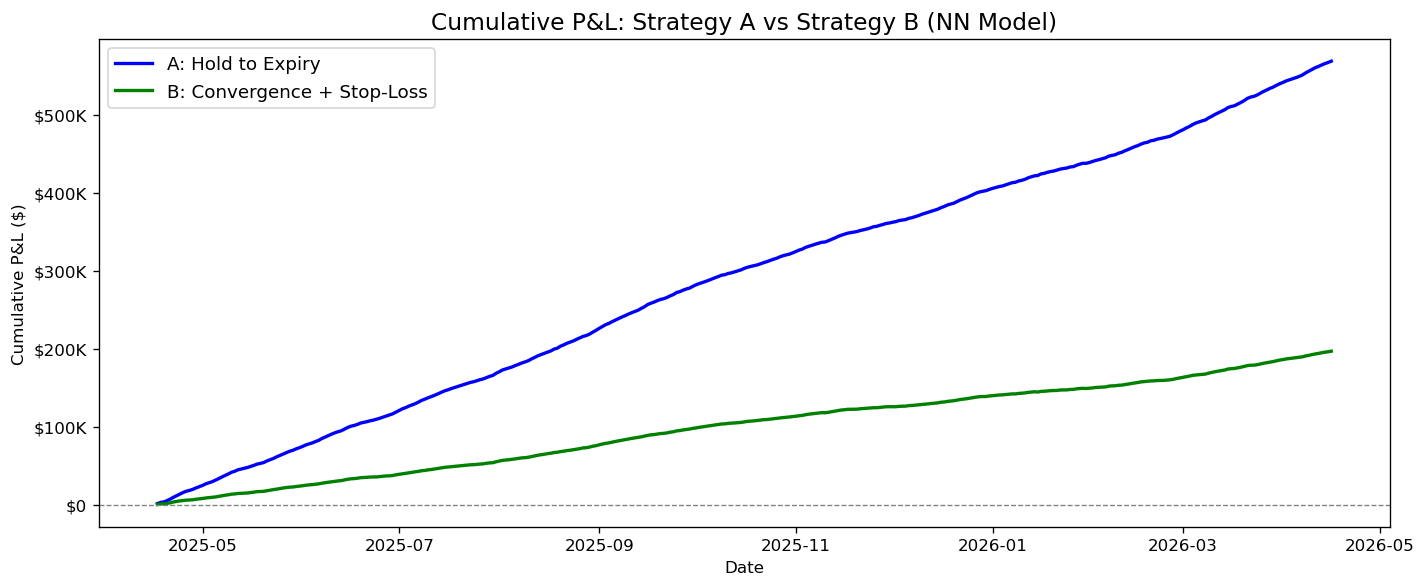

In [6]:
def dollar_fmt(x, _):
    if abs(x) >= 1e6:
        return f"${x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:.0f}K"
    return f"${x:.0f}"

fig, ax = plt.subplots(figsize=(12, 5))
for trades, label, color in [
    (trades_a, "A: Hold to Expiry", "blue"),
    (trades_b, "B: Convergence + Stop-Loss", "green"),
]:
    if not trades.empty:
        daily = trades.groupby("date")["pnl_dollars"].sum().sort_index()
        ax.plot(daily.index, daily.cumsum(), label=label, lw=2, color=color)
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_title("Cumulative P&L: Strategy A vs Strategy B (NN Model)", fontsize=14)
ax.set_ylabel("Cumulative P&L ($)")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

## 7. NN vs NWP Cumulative P&L (Strategy A)

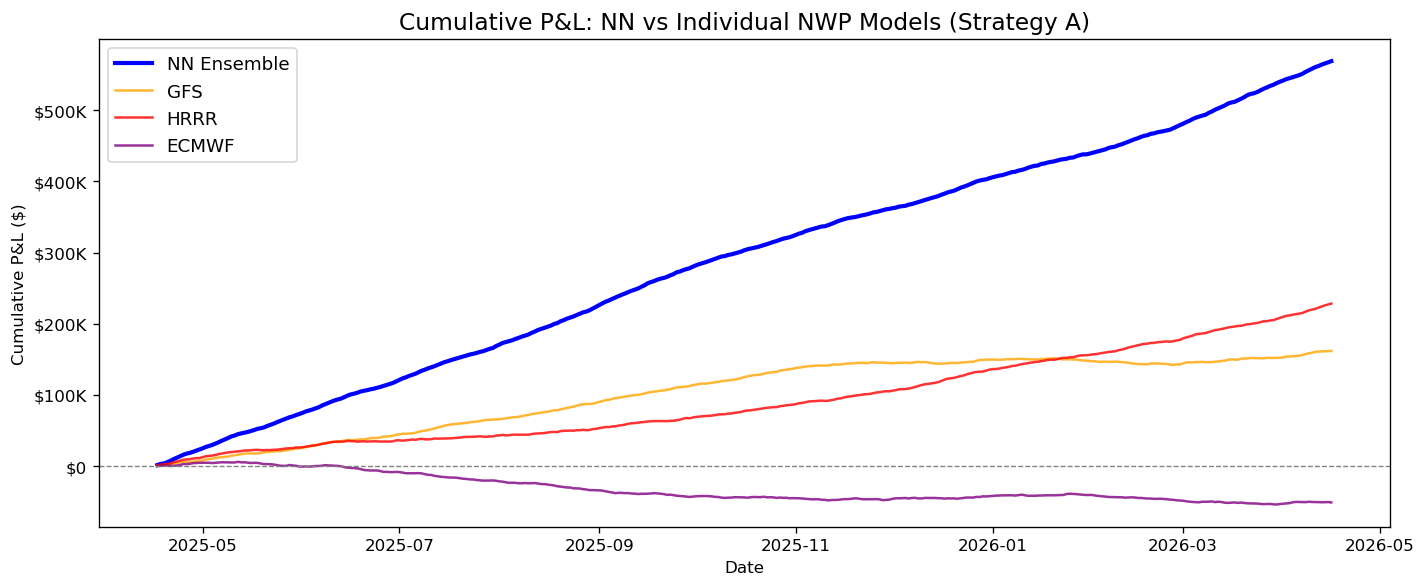

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

# NN
if not trades_a.empty:
    daily_nn = trades_a.groupby("date")["pnl_dollars"].sum().sort_index()
    ax.plot(daily_nn.index, daily_nn.cumsum(), label="NN Ensemble", lw=2.5, color="blue")

# Individual NWP models
nwp_colors = {"GFS": "orange", "HRRR": "red", "ECMWF": "purple"}
for name, res in nwp_results.items():
    t = res["trades_a"]
    if not t.empty:
        daily_m = t.groupby("date")["pnl_dollars"].sum().sort_index()
        ax.plot(daily_m.index, daily_m.cumsum(), label=name, lw=1.5, alpha=0.8,
                color=nwp_colors.get(name, None))

ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_title("Cumulative P&L: NN vs Individual NWP Models (Strategy A)", fontsize=14)
ax.set_ylabel("Cumulative P&L ($)")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

## 8. P&L by City (Strategy A)

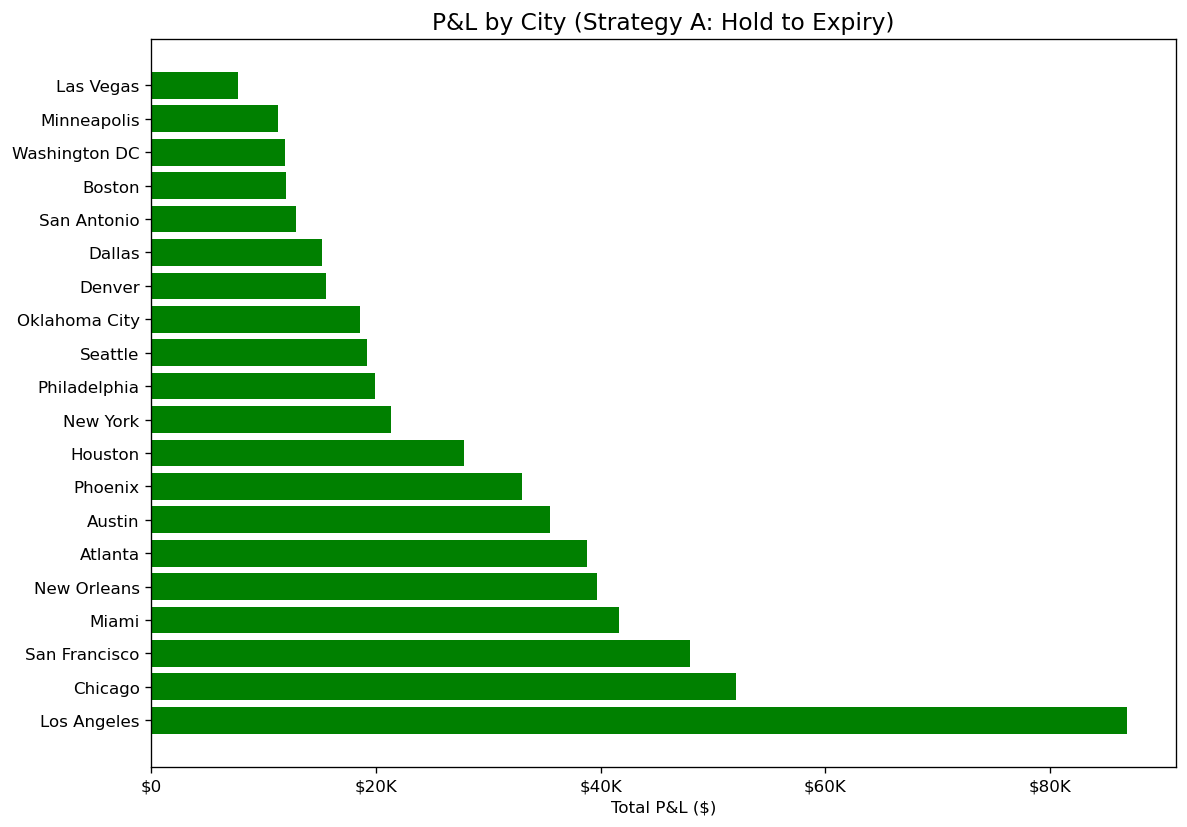

In [8]:
city_pnl = metrics_by_city(trades_a)

fig, ax = plt.subplots(figsize=(10, 7))
if not city_pnl.empty:
    city_names = [cfg.CITIES[t][0] for t in city_pnl.index]
    colors = ["green" if v >= 0 else "red" for v in city_pnl["total_pnl"]]
    ax.barh(city_names, city_pnl["total_pnl"], color=colors)
    ax.set_xlabel("Total P&L ($)")
    ax.set_title("P&L by City (Strategy A: Hold to Expiry)", fontsize=14)
    ax.xaxis.set_major_formatter(FuncFormatter(dollar_fmt))
fig.tight_layout()
plt.show()

## 9. P&L by Month (Strategy A)

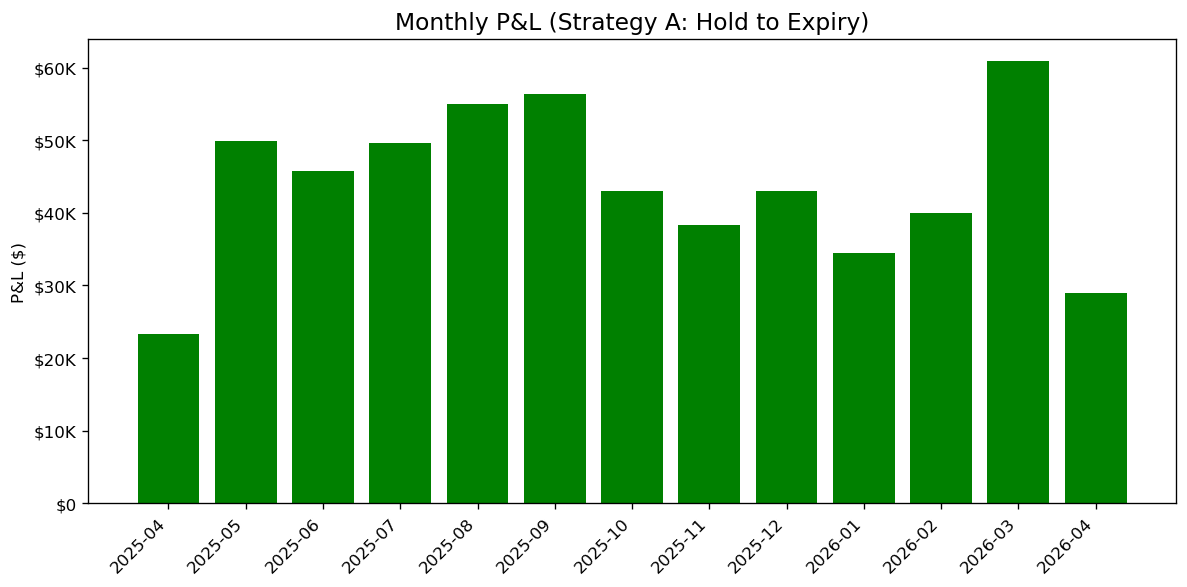

In [9]:
monthly = metrics_by_month(trades_a)

fig, ax = plt.subplots(figsize=(10, 5))
if not monthly.empty:
    colors = ["green" if v >= 0 else "red" for v in monthly["total_pnl"]]
    ax.bar(range(len(monthly)), monthly["total_pnl"], color=colors)
    ax.set_xticks(range(len(monthly)))
    ax.set_xticklabels([str(p) for p in monthly.index], rotation=45, ha="right")
    ax.set_ylabel("P&L ($)")
    ax.set_title("Monthly P&L (Strategy A: Hold to Expiry)", fontsize=14)
    ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
fig.tight_layout()
plt.show()

## 10. Sensitivity Analysis: Sharpe and Win Rate vs Edge Threshold

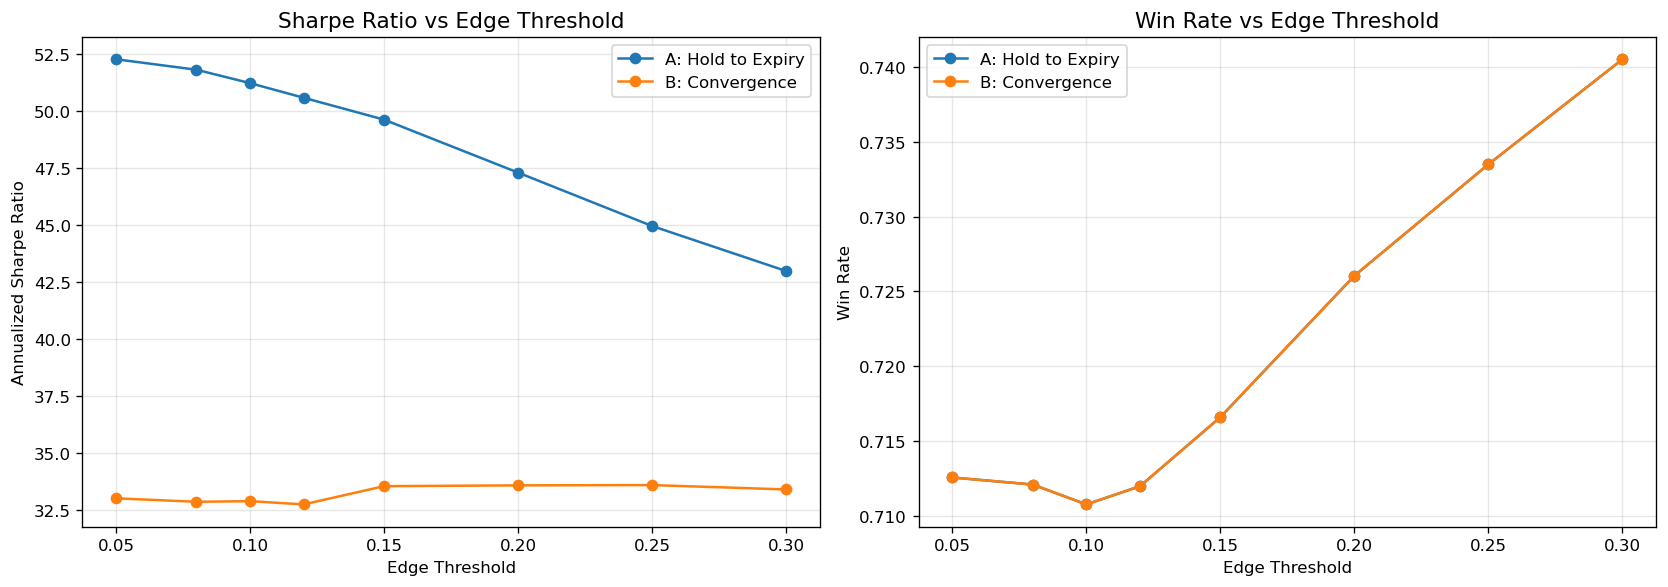

,label,n_trades,total_pnl,avg_pnl_per_trade,win_rate,sharpe,max_drawdown,trading_days,edge_threshold,strategy
0,A_hold_et0.05,11404,607578.533959,53.277669,0.712557,52.279423,-4.510734,365,0.05,A_hold
1,B_convergence_et0.05,11404,202748.907089,17.778754,0.712557,33.005950,-275.247541,365,0.05,B_convergence
2,A_hold_et0.08,9673,585815.257189,60.561900,0.712085,51.819895,-1.587586,365,0.08,A_hold
3,B_convergence_et0.08,9673,199486.691235,20.623043,0.712085,32.853264,-296.207380,365,0.08,B_convergence
4,A_hold_et0.1,8785,568792.449369,64.745868,0.710757,51.232239,-5.490366,365,0.10,A_hold
5,B_convergence_et0.1,8785,196998.951269,22.424468,0.710757,32.881027,-271.172263,365,0.10,B_convergence
6,A_hold_et0.12,8086,550950.820826,68.136386,0.711971,50.589890,-5.349396,365,0.12,A_hold
7,B_convergence_et0.12,8086,194800.308692,24.091060,0.711971,32.738514,-271.172263,365,0.12,B_convergence
8,A_hold_et0.15,7131,529798.264459,74.295087,0.716590,49.628987,0.000000,365,0.15,A_hold
9,B_convergence_et0.15,7131,193545.407315,27.141412,0.716590,33.539020,-282.060617,365,0.15,B_convergence


In [10]:
sensitivity_df = run_sensitivity(contracts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for strat, label in [("A_hold", "A: Hold to Expiry"), ("B_convergence", "B: Convergence")]:
    s = sensitivity_df[sensitivity_df["strategy"] == strat]
    ax1.plot(s["edge_threshold"], s["sharpe"], marker="o", label=label)
    ax2.plot(s["edge_threshold"], s["win_rate"], marker="o", label=label)

ax1.set_xlabel("Edge Threshold")
ax1.set_ylabel("Annualized Sharpe Ratio")
ax1.set_title("Sharpe Ratio vs Edge Threshold", fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.set_xlabel("Edge Threshold")
ax2.set_ylabel("Win Rate")
ax2.set_title("Win Rate vs Edge Threshold", fontsize=13)
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

sensitivity_df

## 11. Stop-Loss Analysis (Strategy B)

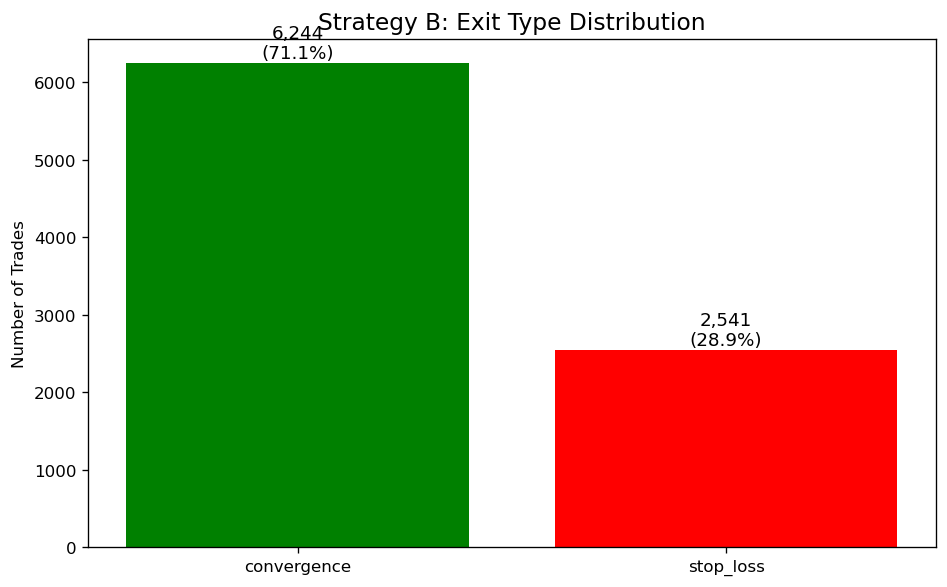

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
if not trades_b.empty and "exit_type" in trades_b.columns:
    exit_counts = trades_b["exit_type"].value_counts()
    bar_colors = {"convergence": "green", "stop_loss": "red"}
    colors = [bar_colors.get(et, "gray") for et in exit_counts.index]
    bars = ax.bar(exit_counts.index, exit_counts.values, color=colors)
    ax.set_ylabel("Number of Trades")
    ax.set_title("Strategy B: Exit Type Distribution", fontsize=14)
    for i, (label, val) in enumerate(exit_counts.items()):
        ax.text(i, val + max(exit_counts.values)*0.01, f"{val:,}\n({val/len(trades_b)*100:.1f}%)",
                ha="center", fontsize=11)
fig.tight_layout()
plt.show()